In [23]:
import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.16.2
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [24]:
import os
os.environ["XLA_FLAGS"] = "--xla_gpu_strict_conv_algorithm_picker=false"

In [25]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices('GPU')
print("GPUs found:", gpus)
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)  # avoids OOM crashes on WSL/local GPUs

TensorFlow version: 2.16.2
GPUs found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [26]:
data = np.load("../utils/week4/cifar-10.npz")
x_train, y_train = data["x_train"], data["y_train"]
x_test, y_test = data["x_test"], data["y_test"]
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

## Preprocessing
Normalize pixel values to 0-1. ANN needs the images flattened into vectors, CNN keeps the 32x32x3 shape.

In [27]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

y_train = y_train.flatten()
y_test = y_test.flatten()

print(x_train_flat.shape, x_test_flat.shape)

(50000, 3072) (10000, 3072)


## Quick look at the data
Check class balance and view a few sample images.

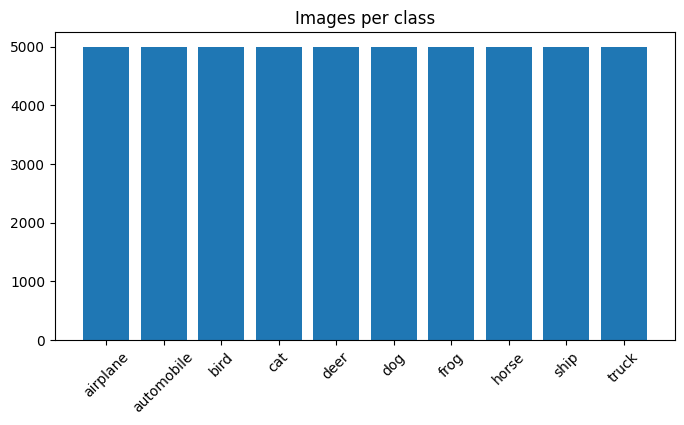

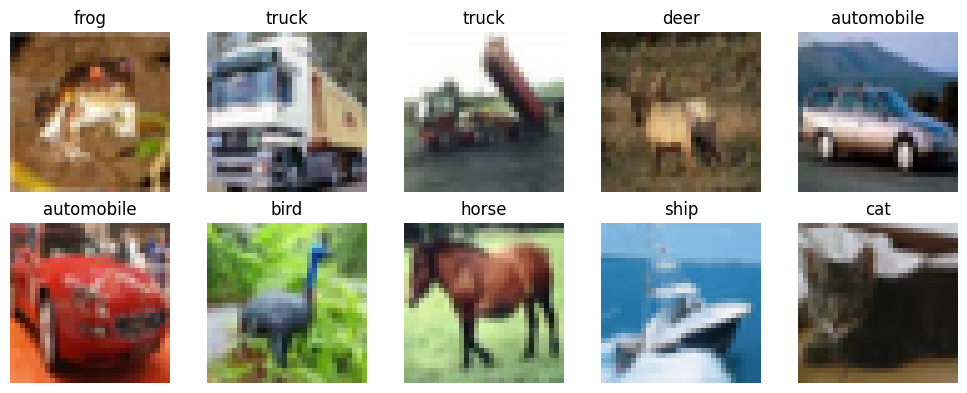

In [28]:
counts = pd.Series(y_train).map(lambda i: class_names[i]).value_counts().sort_index()
plt.figure(figsize=(8, 4))
plt.bar(counts.index, counts.values)
plt.xticks(rotation=45)
plt.title("Images per class")
plt.show()

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

## Part 1: Baseline ANN
Plain fully connected network. It treats the image as a flat vector, so it has no idea about spatial structure.

In [29]:
ann_baseline = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_baseline.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

ann_baseline_history = ann_baseline.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.2750 - loss: 1.9870 - val_accuracy: 0.3298 - val_loss: 1.8300
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3289 - loss: 1.8488 - val_accuracy: 0.3564 - val_loss: 1.7811
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3487 - loss: 1.7972 - val_accuracy: 0.3588 - val_loss: 1.7896
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3593 - loss: 1.7611 - val_accuracy: 0.3954 - val_loss: 1.7137
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.3703 - loss: 1.7353 - val_accuracy: 0.3968 - val_loss: 1.7092
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3846 - loss: 1.7033 - val_accuracy: 0.4132 - val_loss: 1.6649
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3878 - loss: 1.6915 - val_accuracy: 0.4056 - val_loss: 1.6901
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3924 - loss: 1.6771 - val_accuracy:

In [30]:
ann_baseline_loss, ann_baseline_acc = ann_baseline.evaluate(x_test_flat, y_test)
print("Baseline ANN test accuracy:", ann_baseline_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.4348 - loss: 1.6112
Baseline ANN test accuracy: 0.43479999899864197


## Sigmoid vs ReLU
Same small network, only the activation changes. Trained on a 10k subset to keep it quick. Shows how much faster ReLU converges compared to sigmoid.

I0000 00:00:1783884518.500823   18394 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_284', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1783884518.723299   18392 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_284', 428 bytes spill stores, 428 bytes spill loads

I0000 00:00:1783884518.937269   18382 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_284', 436 bytes spill stores, 436 bytes spill loads

I0000 00:00:1783884522.932348   18475 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_138', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1783884523.889915   18479 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_284', 444 bytes spill stores, 444 bytes spill loads

I0000 00:00:1783884524.689581   1

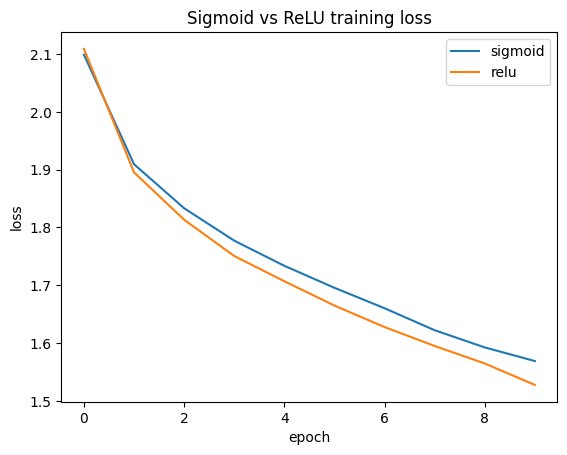

In [31]:
x_sub = x_train_flat[:10000]
y_sub = y_train[:10000]

sigmoid_model = models.Sequential([
    layers.Dense(256, activation='sigmoid', input_shape=(3072,)),
    layers.Dense(128, activation='sigmoid'),
    layers.Dense(10, activation='softmax')
])
sigmoid_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
sigmoid_history = sigmoid_model.fit(x_sub, y_sub, epochs=10, validation_split=0.1, batch_size=64, verbose=0)

relu_model = models.Sequential([
    layers.Dense(256, activation='relu', input_shape=(3072,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])
relu_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
relu_history = relu_model.fit(x_sub, y_sub, epochs=10, validation_split=0.1, batch_size=64, verbose=0)

plt.plot(sigmoid_history.history['loss'], label='sigmoid')
plt.plot(relu_history.history['loss'], label='relu')
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Sigmoid vs ReLU training loss")
plt.legend()
plt.show()

## Task: Deeper ANN
More layers, batch norm, EarlyStopping, 20 epochs. Training stops early once val_loss stops improving.

In [32]:
ann_deep = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_deep.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

ann_deep_history = ann_deep.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.3205 - loss: 1.8912 - val_accuracy: 0.3520 - val_loss: 1.7953
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.3828 - loss: 1.7186 - val_accuracy: 0.3512 - val_loss: 1.7697
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3994 - loss: 1.6719 - val_accuracy: 0.3744 - val_loss: 1.7372
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4106 - loss: 1.6431 - val_accuracy: 0.3948 - val_loss: 1.6952
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.4210 - loss: 1.6169 - val_accuracy: 0.4392 - val_loss: 1.5907
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4260 - loss: 1.6000 - val_accuracy: 0.4476 - val_loss: 1.5705
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4325 - loss: 1.5815 - val_accuracy: 0.4270 - val_loss: 1.6053
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4361 - loss: 1.5723 - val_accuracy

In [33]:
ann_deep_loss, ann_deep_acc = ann_deep.evaluate(x_test_flat, y_test)
print("Deep ANN test accuracy:", ann_deep_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4678 - loss: 1.4921
Deep ANN test accuracy: 0.46779999136924744


## Part 2: Baseline CNN
Convolution keeps spatial structure instead of flattening the image. padding='same' keeps the output size equal to the input, pooling then shrinks it.

In [34]:
cnn_baseline = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_baseline.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    jit_compile=False
)

cnn_baseline_history = cnn_baseline.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.4686 - loss: 1.4958 - val_accuracy: 0.6046 - val_loss: 1.1063
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.6136 - loss: 1.0992 - val_accuracy: 0.5880 - val_loss: 1.1968
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.6786 - loss: 0.9213 - val_accuracy: 0.6568 - val_loss: 1.0111
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.7207 - loss: 0.7919 - val_accuracy: 0.6832 - val_loss: 0.8965
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.7592 - loss: 0.6766 - val_accuracy: 0.7152 - val_loss: 0.8946
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.7875 - loss: 0.5966 - val_accuracy: 0.7226 - val_loss: 0.8598
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.8124 - loss: 0.5196 - val_accuracy: 0.7086 - val_loss: 1.0228
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.8337 - loss: 0.4540 - 

In [35]:
cnn_baseline_loss, cnn_baseline_acc = cnn_baseline.evaluate(x_test_norm, y_test)
print("Baseline CNN test accuracy:", cnn_baseline_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6822 - loss: 1.4059
Baseline CNN test accuracy: 0.682200014591217


## Task: Deeper CNN
More filters, two conv layers per block before pooling, padding='same' to keep sizes consistent. EarlyStopping, 20 epochs.

In [36]:
cnn_deep = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

cnn_deep.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

cnn_deep_history = cnn_deep.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 23ms/step - accuracy: 0.4586 - loss: 1.5985 - val_accuracy: 0.5982 - val_loss: 1.1243
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.6305 - loss: 1.0463 - val_accuracy: 0.6658 - val_loss: 0.9481
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6863 - loss: 0.8932 - val_accuracy: 0.7206 - val_loss: 0.7881
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7202 - loss: 0.7946 - val_accuracy: 0.7470 - val_loss: 0.7418
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7485 - loss: 0.7239 - val_accuracy: 0.7446 - val_loss: 0.7401
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7627 - loss: 0.6780 - val_accuracy: 0.7886 - val_loss: 0.6131
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7758 - loss: 0.6358 - val_accuracy: 0.7866 - val_loss: 0.6198
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7900 - loss: 0.6024 - val_accuracy: 

In [37]:
cnn_deep_loss, cnn_deep_acc = cnn_deep.evaluate(x_test_norm, y_test)
print("Deep CNN test accuracy:", cnn_deep_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.8185 - loss: 0.5439
Deep CNN test accuracy: 0.8184999823570251


## Task: Data augmentation
Random flips, rotation and zoom generate slightly different images every epoch, which helps reduce overfitting. Same architecture as the deep CNN above.

In [38]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

cnn_aug = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

cnn_aug.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

cnn_aug_history = cnn_aug.fit(
    x_train_norm, y_train,
    epochs=15,
    validation_split=0.1,
    batch_size=64,
    callbacks=[callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]
)

Epoch 1/15


2026-07-12 19:37:14.011595: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_12_1/dropout_21_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 56ms/step - accuracy: 0.3913 - loss: 1.8017 - val_accuracy: 0.5302 - val_loss: 1.2880
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 55ms/step - accuracy: 0.5174 - loss: 1.3462 - val_accuracy: 0.5590 - val_loss: 1.3202
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 55ms/step - accuracy: 0.5753 - loss: 1.1969 - val_accuracy: 0.6262 - val_loss: 1.0906
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.6102 - loss: 1.1031 - val_accuracy: 0.6480 - val_loss: 1.0275
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 54ms/step - accuracy: 0.6364 - loss: 1.0334 - val_accuracy: 0.6802 - val_loss: 0.9316
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 53ms/step - accuracy: 0.6590 - loss: 0.9828 - val_accuracy: 0.6400 - val_loss: 1.0675
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 54ms/step - accuracy: 0.6720 - loss: 0.9368 - val_accuracy: 0.6982 - val_loss: 0.8918
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 54ms/step - accuracy: 0.6824 - loss: 0.9079 - val_accurac

In [39]:
cnn_aug_loss, cnn_aug_acc = cnn_aug.evaluate(x_test_norm, y_test)
print("Augmented CNN test accuracy:", cnn_aug_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.7448 - loss: 0.7345
Augmented CNN test accuracy: 0.7447999715805054


## Comparing all models

In [40]:
results = pd.DataFrame({
    "Model": ["ANN deep", "CNN deep", "CNN augmented"],
    "Test Accuracy": [ann_deep_acc, cnn_deep_acc, cnn_aug_acc],
    "Test Loss": [ann_deep_loss, cnn_deep_loss, cnn_aug_loss]
}).sort_values("Test Accuracy", ascending=False).reset_index(drop=True)

results

,Model,Test Accuracy,Test Loss
0,CNN deep,0.8185,0.543926
1,CNN augmented,0.7448,0.734536
2,ANN deep,0.4678,1.492147


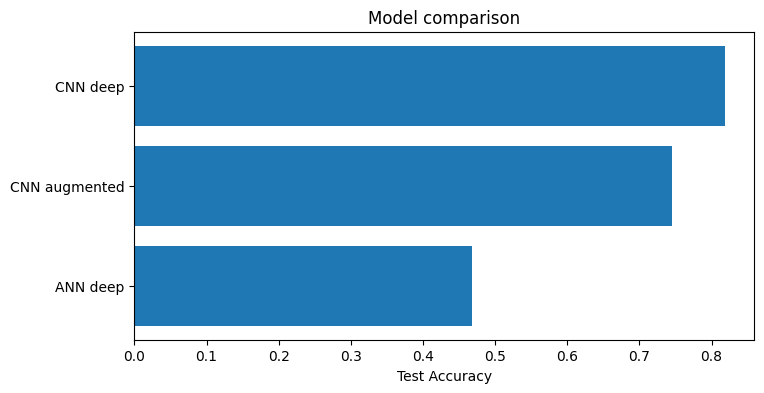

In [41]:
plt.figure(figsize=(8, 4))
plt.barh(results["Model"], results["Test Accuracy"])
plt.xlabel("Test Accuracy")
plt.title("Model comparison")
plt.gca().invert_yaxis()
plt.show()

## Learning curves
Train vs validation accuracy and loss for all three models.

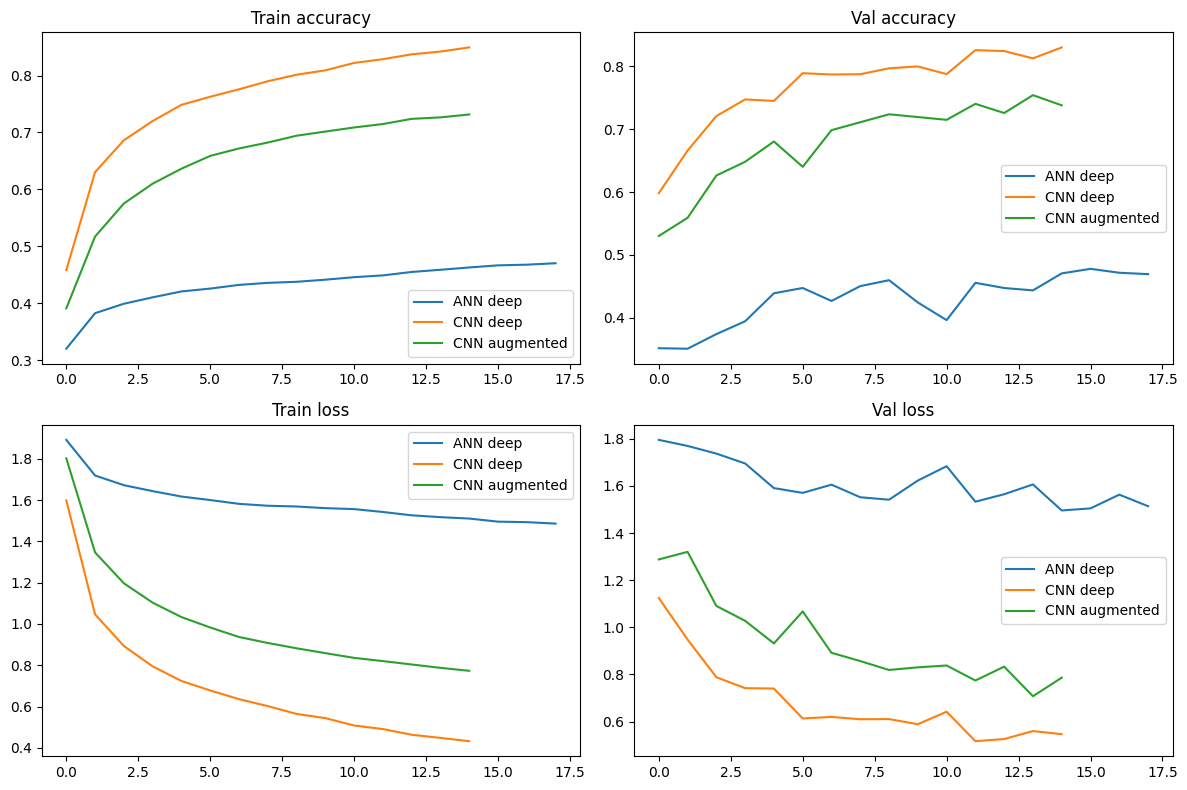

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

histories = {
    "ANN deep": ann_deep_history,
    "CNN deep": cnn_deep_history,
    "CNN augmented": cnn_aug_history
}

for name, h in histories.items():
    axes[0, 0].plot(h.history['accuracy'], label=name)
    axes[0, 1].plot(h.history['val_accuracy'], label=name)
    axes[1, 0].plot(h.history['loss'], label=name)
    axes[1, 1].plot(h.history['val_loss'], label=name)

axes[0, 0].set_title("Train accuracy")
axes[0, 1].set_title("Val accuracy")
axes[1, 0].set_title("Train loss")
axes[1, 1].set_title("Val loss")
for ax in axes.flat:
    ax.legend()

plt.tight_layout()
plt.show()

## Confusion matrix
Using whichever model scored highest on test accuracy.

Best model: CNN deep
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


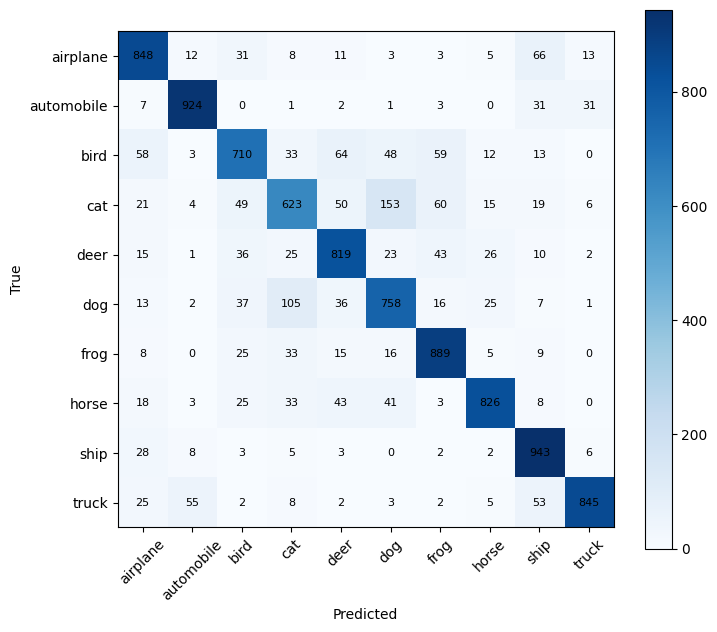

              precision    recall  f1-score   support

    airplane       0.81      0.85      0.83      1000
  automobile       0.91      0.92      0.92      1000
        bird       0.77      0.71      0.74      1000
         cat       0.71      0.62      0.66      1000
        deer       0.78      0.82      0.80      1000
         dog       0.72      0.76      0.74      1000
        frog       0.82      0.89      0.85      1000
       horse       0.90      0.83      0.86      1000
        ship       0.81      0.94      0.87      1000
       truck       0.93      0.84      0.89      1000

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.82     10000
weighted avg       0.82      0.82      0.82     10000



In [43]:
best_model_name = results.iloc[0]["Model"]
print("Best model:", best_model_name)

if best_model_name == "CNN augmented":
    y_pred = np.argmax(cnn_aug.predict(x_test_norm), axis=1)
elif best_model_name == "CNN deep":
    y_pred = np.argmax(cnn_deep.predict(x_test_norm), axis=1)
else:
    y_pred = np.argmax(ann_deep.predict(x_test_flat), axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 7))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks(range(10), class_names, rotation=45)
plt.yticks(range(10), class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=8)
plt.show()

print(classification_report(y_test, y_pred, target_names=class_names))

## Misclassified examples

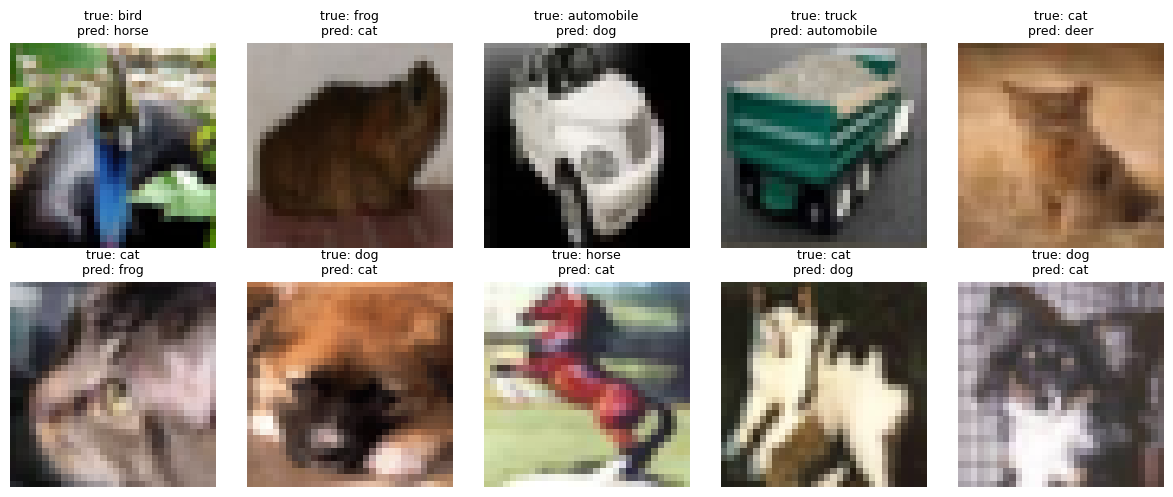

In [44]:
wrong = np.where(y_pred != y_test)[0]
sample = np.random.choice(wrong, 10, replace=False)

plt.figure(figsize=(12, 5))
for i, idx in enumerate(sample):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[idx])
    plt.title(f"true: {class_names[y_test[idx]]}\npred: {class_names[y_pred[idx]]}", fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

## Conclusion
CNN beats ANN because it preserves spatial structure instead of flattening the image. Going deeper with more filters increases capacity but needs EarlyStopping to avoid overfitting at 20 epochs. Augmentation narrows the gap between train and validation accuracy, showing less overfitting than the plain deep CNN.